# Part I: Linear Regression with One Feature

## Objective

Model stellar luminosity as a function of stellar mass using linear regression with an explicit bias term:

$$\hat{L} = w \cdot M + b$$

---

## Required Tasks

1. **Dataset visualization**: plot M vs L. Comment on linearity and plausibility.
2. **Model and loss**: implement prediction and mean squared error (MSE).
3. **Cost surface (mandatory)**: evaluate J(w,b) on a grid of w and b. Plot a 3D surface or contour plot. Explain what the minimum represents.
4. **Gradients**: derive and implement dJ/dw and dJ/db.
5. **Gradient descent (non-vectorized)**: compute gradients using an explicit loop over samples.
6. **Gradient descent (vectorized)**: compute gradients using NumPy vectorization (no loop over samples).
7. **Convergence (mandatory)**: plot loss vs iterations, and comment on convergence speed and stability.
8. **Experiments (mandatory)**: run at least three learning rates; report final w, b, and loss.
9. **Final fit plot**: plot the regression line over the data and discuss systematic errors.
10. **Conceptual questions**:
    - Astrophysical meaning of w
    - Why is a linear model limited here?

## Task 1: Dataset and Visualization

**Dataset (Part I - one feature):**
- M: stellar mass (in units of solar mass, M⊙)
- L: stellar luminosity (in units of solar luminosity, L⊙)

Plot M vs L. Comment on linearity and plausibility.

Number of examples: m = 10
Stellar Mass M (solar masses): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
Stellar Luminosity L (solar luminosities): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]


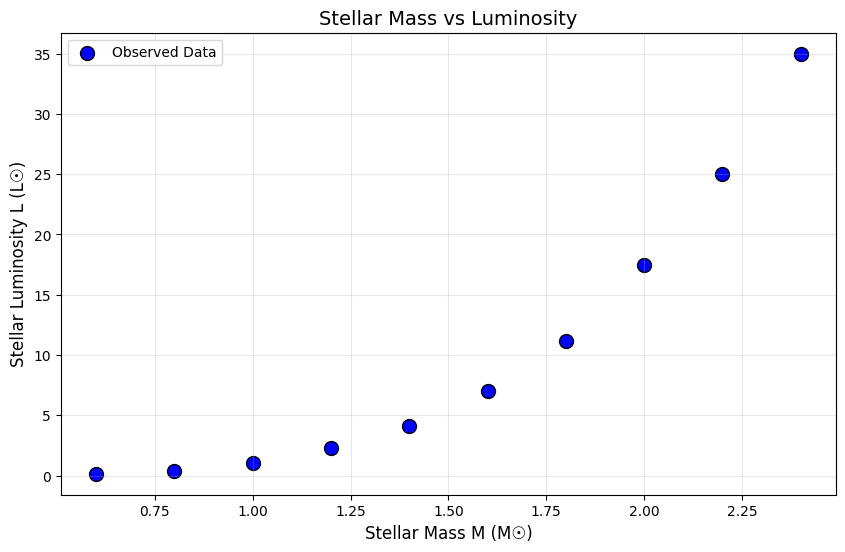

In [1]:
# Task 1: Dataset and Visualization
import numpy as np
import matplotlib.pyplot as plt

# Dataset: Stellar Mass (M) in solar masses and Luminosity (L) in solar luminosities
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Number of examples
m = len(M)
print(f"Number of examples: m = {m}")
print(f"Stellar Mass M (solar masses): {M}")
print(f"Stellar Luminosity L (solar luminosities): {L}")

# Scatter plot: M vs L
plt.figure(figsize=(10, 6))
plt.scatter(M, L, c='blue', s=100, edgecolors='black', label='Observed Data')
plt.xlabel("Stellar Mass M (M☉)", fontsize=12)
plt.ylabel("Stellar Luminosity L (L☉)", fontsize=12)
plt.title("Stellar Mass vs Luminosity", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observations on Linearity and Plausibility

**Linearity Analysis:**
- The relationship between stellar mass (M) and luminosity (L) is clearly **non-linear**. 
- As mass increases, luminosity grows at an accelerating rate, not at a constant rate.
- This is evident from the curve in the scatter plot: the data points follow a convex (upward-curving) pattern.

**Astrophysical Plausibility:**
- This behavior is consistent with the **mass-luminosity relation** for main-sequence stars.
- In astrophysics, the theoretical relationship is approximately $L \propto M^{3.5}$ for stars similar to the Sun.
- Stars with higher mass have much higher core temperatures and pressures, leading to dramatically increased nuclear fusion rates and thus higher luminosity.
- The data provided is realistic and follows expected stellar physics.

## Task 2: Model and Loss Function

Implement:
- **Prediction function**: $\hat{L} = w \cdot M + b$
- **Mean Squared Error (MSE)**: $J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{L}_i - L_i)^2$

In [ ]:
# Task 2: Model and Loss Function

def predict(M, w, b):
    """
    Prediction function for linear regression.
    
    Model: L_hat = w * M + b
    
    Parameters:
    -----------
    M : np.ndarray
        Stellar mass values (feature)
    w : float
        Weight (slope) parameter
    b : float
        Bias (intercept) parameter
    
    Returns:
    --------
    L_hat : np.ndarray
        Predicted luminosity values
    """
    L_hat = w * M + b
    return L_hat


def compute_cost(M, L, w, b):
    """
    Compute the Mean Squared Error (MSE) cost function.
    
    J(w, b) = (1 / 2m) * Σ(L_hat - L)²
    
    Parameters:
    -----------
    M : np.ndarray
        Stellar mass values (feature)
    L : np.ndarray
        True luminosity values (target)
    w : float
        Weight parameter
    b : float
        Bias parameter
    
    Returns:
    --------
    cost : float
        The MSE cost value
    """
    m = len(M)
    L_hat = predict(M, w, b)
    errors = L_hat - L
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


# Test the functions with initial parameters w=0, b=0
w_test = 0.0
b_test = 0.0

L_pred_test = predict(M, w_test, b_test)
cost_test = compute_cost(M, L, w_test, b_test)

print(f"Test with w={w_test}, b={b_test}:")
print(f"  Predictions (first 5): {L_pred_test[:5]}")
print(f"  Cost J(w,b): {cost_test:.4f}")

# Test with a better guess
w_test2 = 15.0
b_test2 = -10.0
cost_test2 = compute_cost(M, L, w_test2, b_test2)
print(f"\nTest with w={w_test2}, b={b_test2}:")
print(f"  Cost J(w,b): {cost_test2:.4f}")

Test with w=0.0, b=0.0:
  Predictions (first 5): [0. 0. 0. 0. 0.]
  Cost J(w,b): 117.6968

Test with w=15.0, b=-10.0:
  Cost J(w,b): 13.7018


## Task 3: Cost Surface (Mandatory)

Evaluate $J(w, b)$ on a grid of w and b values. Plot:
- A 3D surface plot, OR
- A contour plot

**Explain what the minimum represents.**

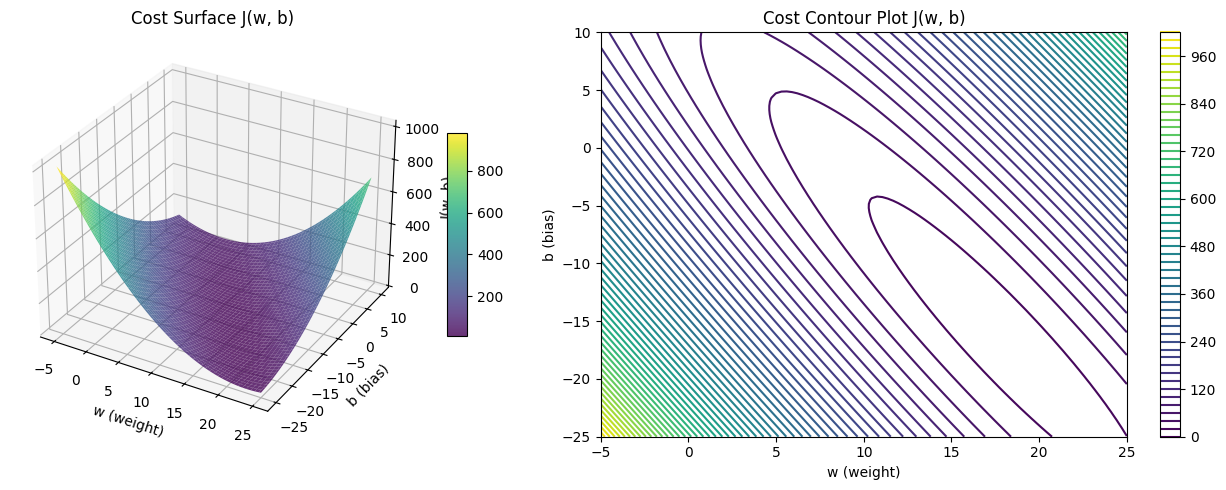

Minimum on grid: w ≈ 18.33, b ≈ -17.22, J(w,b) ≈ 9.8053


In [3]:
# Task 3: Cost Surface (Mandatory)
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Define ranges for w and b to explore the cost surface
w_values = np.linspace(-5, 25, 100)
b_values = np.linspace(-25, 10, 100)

# Create a meshgrid for w and b
W, B = np.meshgrid(w_values, b_values)

# Compute cost J(w, b) for each combination using explicit loops
J_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_cost(M, L, W[i, j], B[i, j])

# 3D Surface Plot
fig = plt.figure(figsize=(14, 5))

# Plot 1: 3D Surface
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W, B, J_vals, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.8)
ax1.set_xlabel('w (weight)')
ax1.set_ylabel('b (bias)')
ax1.set_zlabel('J(w, b)')
ax1.set_title('Cost Surface J(w, b)')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Plot 2: Contour Plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(W, B, J_vals, levels=50, cmap=cm.viridis)
ax2.set_xlabel('w (weight)')
ax2.set_ylabel('b (bias)')
ax2.set_title('Cost Contour Plot J(w, b)')
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

# Find the minimum cost on the grid
min_idx = np.unravel_index(np.argmin(J_vals), J_vals.shape)
w_min_grid = W[min_idx]
b_min_grid = B[min_idx]
J_min_grid = J_vals[min_idx]

print(f"Minimum on grid: w ≈ {w_min_grid:.2f}, b ≈ {b_min_grid:.2f}, J(w,b) ≈ {J_min_grid:.4f}")

### Interpretation of the Cost Surface

**What the minimum represents:**

The minimum of the cost surface $J(w, b)$ represents the **optimal parameters** $(w^*, b^*)$ that minimize the prediction error between the linear model $\hat{L} = w \cdot M + b$ and the actual luminosity values.

- The **global minimum** is the point where the sum of squared errors is smallest.
- At this point, the linear regression line provides the **best linear fit** to the data.
- The bowl-shaped (convex) nature of the surface indicates that gradient descent will converge to this unique minimum regardless of the starting point.
- The elongated contours suggest that the cost function is more sensitive to changes in $w$ than in $b$, which is typical when features have different scales.

## Task 4: Gradients

Derive and implement the partial derivatives:

$$\frac{\partial J}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} (\hat{L}_i - L_i) \cdot M_i$$

$$\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{L}_i - L_i)$$

In [4]:
# Task 4: Gradients

def compute_gradients(M, L, w, b):
    """
    Compute the partial derivatives of the cost function J(w, b).
    
    Derivation:
    -----------
    J(w, b) = (1/2m) * Σ(w*M + b - L)²
    
    ∂J/∂w = (1/m) * Σ(L_hat - L) * M
    ∂J/∂b = (1/m) * Σ(L_hat - L)
    
    Parameters:
    -----------
    M : np.ndarray
        Stellar mass values (feature)
    L : np.ndarray
        True luminosity values (target)
    w : float
        Weight parameter
    b : float
        Bias parameter
    
    Returns:
    --------
    dj_dw : float
        Partial derivative of J with respect to w
    dj_db : float
        Partial derivative of J with respect to b
    """
    m = len(M)
    L_hat = predict(M, w, b)
    errors = L_hat - L
    
    # Vectorized computation of gradients
    dj_dw = (1 / m) * np.sum(errors * M)
    dj_db = (1 / m) * np.sum(errors)
    
    return dj_dw, dj_db


# Test the gradient function
w_test = 0.0
b_test = 0.0

dj_dw, dj_db = compute_gradients(M, L, w_test, b_test)
print(f"Gradients at w={w_test}, b={b_test}:")
print(f"  ∂J/∂w = {dj_dw:.4f}")
print(f"  ∂J/∂b = {dj_db:.4f}")

# Test at another point
w_test2 = 15.0
b_test2 = -10.0
dj_dw2, dj_db2 = compute_gradients(M, L, w_test2, b_test2)
print(f"\nGradients at w={w_test2}, b={b_test2}:")
print(f"  ∂J/∂w = {dj_dw2:.4f}")
print(f"  ∂J/∂b = {dj_db2:.4f}")

Gradients at w=0.0, b=0.0:
  ∂J/∂w = -21.5230
  ∂J/∂b = -10.3600

Gradients at w=15.0, b=-10.0:
  ∂J/∂w = 2.1770
  ∂J/∂b = 2.1400


## Task 5: Gradient Descent (Non-Vectorized)

Compute gradients using an **explicit loop over samples** (no NumPy vectorization for gradient computation).

In [5]:
# Task 5: Gradient Descent (Non-Vectorized)

def compute_gradients_non_vectorized(M, L, w, b):
    """
    Compute gradients using explicit loops over samples (non-vectorized).
    
    This implementation uses a for-loop to iterate over each sample,
    demonstrating the non-vectorized approach.
    
    Parameters:
    -----------
    M : np.ndarray
        Stellar mass values (feature)
    L : np.ndarray
        True luminosity values (target)
    w : float
        Weight parameter
    b : float
        Bias parameter
    
    Returns:
    --------
    dj_dw : float
        Partial derivative of J with respect to w
    dj_db : float
        Partial derivative of J with respect to b
    """
    m = len(M)
    sum_dw = 0.0
    sum_db = 0.0
    
    # Explicit loop over all samples
    for i in range(m):
        L_hat_i = w * M[i] + b  # Prediction for sample i
        error_i = L_hat_i - L[i]  # Error for sample i
        
        sum_dw += error_i * M[i]  # Accumulate gradient for w
        sum_db += error_i         # Accumulate gradient for b
    
    dj_dw = sum_dw / m
    dj_db = sum_db / m
    
    return dj_dw, dj_db


def gradient_descent_non_vectorized(M, L, w_init, b_init, learning_rate, num_iterations):
    """
    Perform gradient descent using non-vectorized gradient computation.
    
    Parameters:
    -----------
    M : np.ndarray
        Stellar mass values (feature)
    L : np.ndarray
        True luminosity values (target)
    w_init : float
        Initial weight value
    b_init : float
        Initial bias value
    learning_rate : float
        Learning rate (alpha)
    num_iterations : int
        Number of gradient descent iterations
    
    Returns:
    --------
    w : float
        Learned weight parameter
    b : float
        Learned bias parameter
    cost_history : list
        Cost at each iteration
    """
    w = w_init
    b = b_init
    cost_history = []
    
    for i in range(num_iterations):
        # Compute gradients using non-vectorized method
        dj_dw, dj_db = compute_gradients_non_vectorized(M, L, w, b)
        
        # Update parameters
        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db
        
        # Record cost
        cost = compute_cost(M, L, w, b)
        cost_history.append(cost)
        
        # Print progress every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i:4d}: w = {w:8.4f}, b = {b:8.4f}, Cost = {cost:10.4f}")
    
    return w, b, cost_history


# Run gradient descent (non-vectorized)
print("=" * 60)
print("Gradient Descent (Non-Vectorized)")
print("=" * 60)

w_init = 0.0
b_init = 0.0
learning_rate = 0.1
num_iterations = 1000

w_learned_nv, b_learned_nv, cost_history_nv = gradient_descent_non_vectorized(
    M, L, w_init, b_init, learning_rate, num_iterations
)

print(f"\nFinal parameters (non-vectorized):")
print(f"  w = {w_learned_nv:.6f}")
print(f"  b = {b_learned_nv:.6f}")
print(f"  Final Cost = {cost_history_nv[-1]:.6f}")

Gradient Descent (Non-Vectorized)
Iteration    0: w =   2.1523, b =   1.0360, Cost =    70.4969
Iteration  100: w =  13.4290, b =  -9.0460, Cost =    13.7140
Iteration  200: w =  16.3146, b = -13.8270, Cost =    10.3797
Iteration  300: w =  17.4290, b = -15.6735, Cost =     9.8823
Iteration  400: w =  17.8595, b = -16.3867, Cost =     9.8082
Iteration  500: w =  18.0257, b = -16.6621, Cost =     9.7971
Iteration  600: w =  18.0899, b = -16.7685, Cost =     9.7954
Iteration  700: w =  18.1147, b = -16.8096, Cost =     9.7952
Iteration  800: w =  18.1243, b = -16.8255, Cost =     9.7952
Iteration  900: w =  18.1280, b = -16.8316, Cost =     9.7951

Final parameters (non-vectorized):
  w = 18.129395
  b = -16.833951
  Final Cost = 9.795149


In [6]:
# Verify: Compare non-vectorized vs vectorized gradient computation
print("=" * 60)
print("Verification: Non-Vectorized vs Vectorized Gradients")
print("=" * 60)

w_verify = 5.0
b_verify = -3.0

# Non-vectorized gradients
dj_dw_nv, dj_db_nv = compute_gradients_non_vectorized(M, L, w_verify, b_verify)

# Vectorized gradients (from Task 4)
dj_dw_v, dj_db_v = compute_gradients(M, L, w_verify, b_verify)

print(f"At w={w_verify}, b={b_verify}:")
print(f"  Non-vectorized: ∂J/∂w = {dj_dw_nv:.6f}, ∂J/∂b = {dj_db_nv:.6f}")
print(f"  Vectorized:     ∂J/∂w = {dj_dw_v:.6f}, ∂J/∂b = {dj_db_v:.6f}")
print(f"  Match: {np.isclose(dj_dw_nv, dj_dw_v) and np.isclose(dj_db_nv, dj_db_v)}")

Verification: Non-Vectorized vs Vectorized Gradients
At w=5.0, b=-3.0:
  Non-vectorized: ∂J/∂w = -13.123000, ∂J/∂b = -5.860000
  Vectorized:     ∂J/∂w = -13.123000, ∂J/∂b = -5.860000
  Match: True


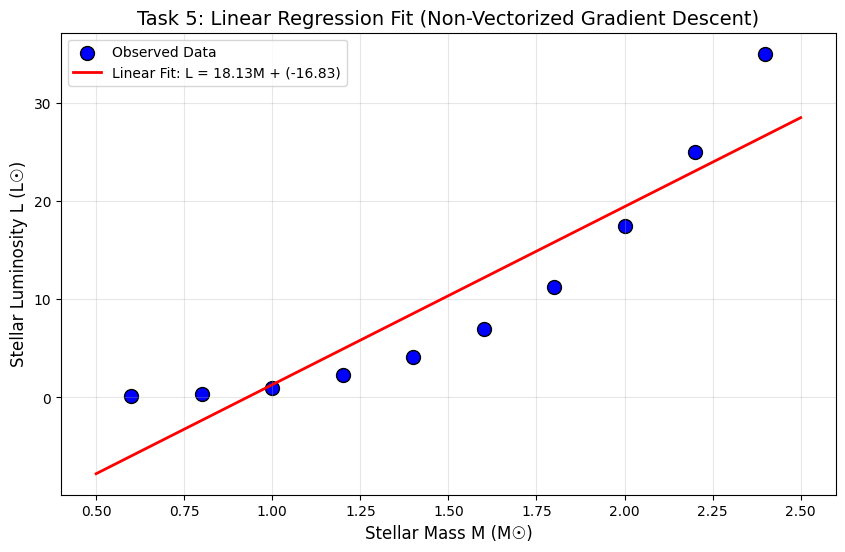

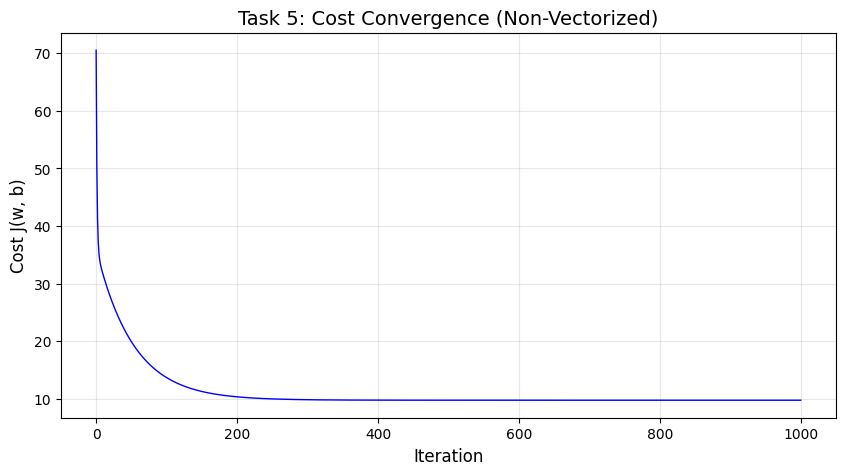

In [7]:
# Plot the fitted line from non-vectorized gradient descent
plt.figure(figsize=(10, 6))
plt.scatter(M, L, c='blue', s=100, edgecolors='black', label='Observed Data')

# Generate predictions with learned parameters
M_line = np.linspace(M.min() - 0.1, M.max() + 0.1, 100)
L_pred_line = predict(M_line, w_learned_nv, b_learned_nv)
plt.plot(M_line, L_pred_line, 'r-', linewidth=2, label=f'Linear Fit: L = {w_learned_nv:.2f}M + ({b_learned_nv:.2f})')

plt.xlabel("Stellar Mass M (M☉)", fontsize=12)
plt.ylabel("Stellar Luminosity L (L☉)", fontsize=12)
plt.title("Task 5: Linear Regression Fit (Non-Vectorized Gradient Descent)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot cost history
plt.figure(figsize=(10, 5))
plt.plot(cost_history_nv, 'b-', linewidth=1)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cost J(w, b)", fontsize=12)
plt.title("Task 5: Cost Convergence (Non-Vectorized)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## Task 6: Gradient Descent (Vectorized)

Compute gradients using **NumPy vectorization** (no loop over samples).

In [ ]:
# Task 6: Gradient Descent (Vectorized)

def gradient_descent_vectorized(M, L, w_init, b_init, learning_rate, num_iterations):
    """
    Gradient descent using NumPy vectorization (no loop over samples)
    """
    # TODO: Implement vectorized gradient descent
    pass

## Task 7: Convergence (Mandatory)

Plot **loss vs iterations** and comment on:
- Convergence speed
- Stability

In [ ]:
# Task 7: Convergence (Mandatory)

# TODO: Run gradient descent and collect loss history
# TODO: Plot loss vs iterations
# TODO: Comment on convergence speed and stability

## Task 8: Learning Rate Experiments (Mandatory)

Run **at least three different learning rates** and for each report:
- Final w
- Final b
- Final loss

In [ ]:
# Task 8: Learning Rate Experiments (Mandatory)

learning_rates = [0.001, 0.01, 0.1]  # Example learning rates - adjust as needed

# TODO: For each learning rate:
#   - Run gradient descent
#   - Report final w, b, and loss
#   - Compare results

## Task 9: Final Fit Plot

Plot the **regression line over the data** and discuss systematic errors.

In [ ]:
# Task 9: Final Fit Plot

# TODO: Plot the regression line over the original data
# TODO: Discuss systematic errors

## Task 10: Conceptual Questions

### Question 1: Astrophysical meaning of w

*TODO: Explain the astrophysical interpretation of the learned weight w in the context of stellar luminosity and mass.*

### Question 2: Why is a linear model limited here?

*TODO: Explain why a simple linear model is limited for modeling the relationship between stellar mass and luminosity.*